# CW305 MNIST Neural Network Classifier — Power Trace Capture

This notebook implements a fully connected neural network (784-64-64-32-10) on the CW305 FPGA board for MNIST digit classification.
It demonstrates:
1. Loading MNIST data from a CSV file.
2. Transferring image data to the FPGA via USB registers.
3. Triggering the NN classification and capturing power traces.
4. Reading the classification result and comparing it with the label.

In [12]:
import chipwhisperer as cw
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

BITFILE      = 'test2/test2.runs/impl_1/cw305_top.bit'
DEFINES_FILE = 'test2.srcs/sources_1/new/cw305_user_defines.v'
DATASET_FILE = 'MNIST-10000-784.csv'

print(f'ChipWhisperer version: {cw.__version__}')

ChipWhisperer version: 6.0.0


## 1 — Connect to Scope and Target

In [13]:
scope = cw.scope()
scope.default_setup()

class MyCW305(cw.targets.CW305):
    def __init__(self):
        super().__init__()
        self.registers      = 5   # Number of `define REG_NN_* in defines file
        self.bytecount_size = 7

target = cw.target(scope, MyCW305,
                   bsfile        = BITFILE,
                   force         = True,
                   fpga_id       = '100t',
                   platform      = 'cw305',
                   defines_files = [DEFINES_FILE])

print('FPGA Programmed and Registers Parsed.')

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 23817885                  to 110735486                
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 96000000                  to 29538459                 
scope.clock.adc_rate                     changed from 96000000.0                to 29538459.0               
scope.clock.clkgen_

## 2 — Configure Clock and Capture

In [14]:
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(False, 0)
target.pll.pll_outenable_set(True,  1)
target.pll.pll_outenable_set(False, 2)
target.pll.pll_outfreq_set(10e6, 1)

scope.io.hs2 = 'disabled'
scope.clock.adc_src = 'extclk_x4'
scope.clock.reset_adc()
time.sleep(0.2)
assert scope.clock.adc_locked, 'ADC failed to lock to FPGA clock.'

# ADC Configuration:
# scope.adc.samples: The total number of data points to record after a trigger.
# Synchronous Sampling: Using extclk_x4 means 4 samples are taken PER FPGA clock cycle.
# At 10 MHz (100ns period), we get a sample every 25ns (40 MS/s).
# 10,000 samples = 2,500 FPGA clock cycles = 250 microseconds of capture time.
scope.adc.samples = 10000 # NN takes time
scope.adc.offset = 0
scope.trigger.triggers = 'tio4'
print(f'ADC locked. Samples: {scope.adc.samples}')

ADC locked. Samples: 10000


## 3 — Load MNIST Dataset

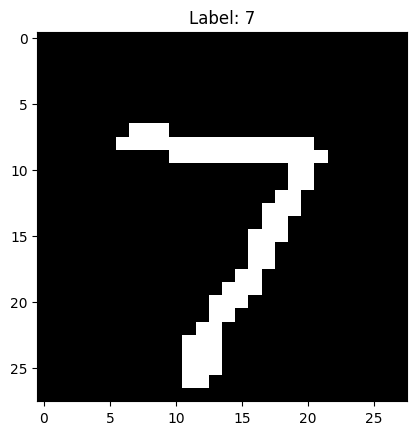

In [15]:
df = pd.read_csv(DATASET_FILE)
labels = df['label'].values
pixels = df.drop('label', axis=1).values

def get_binary_image(index):
    img = pixels[index]
    img_bin = (img > 127).astype(np.uint8)
    return img_bin, labels[index]

img, label = get_binary_image(0)
plt.imshow(img.reshape(28,28), cmap='gray')
plt.title(f'Label: {label}')
plt.show()

In [11]:
df.head(10)

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


## 4 — Classification and Trace Capture

Image 0 - Actual: 7, Predicted: 1


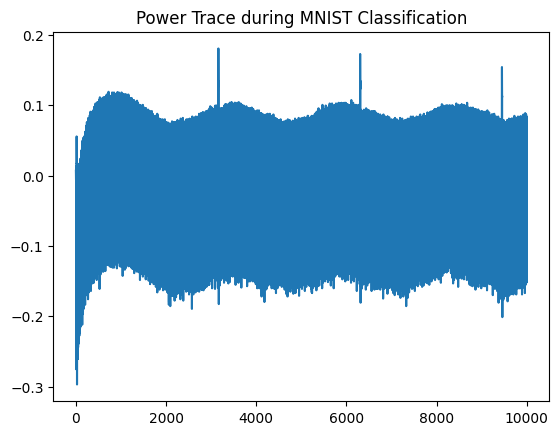

In [16]:
import plotly.graph_objects as go
import numpy as np

# Calculate time axis
# Sampling rate = FPGA_CLK * 4 (because of extclk_x4)
fpga_clk = 10e6 
sampling_rate = fpga_clk * 4
time_axis = np.arange(len(trace)) / sampling_rate

fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(len(trace)), y=trace, name="Power Trace",
                         text=[f"{t*1e6:.2f} us" for t in time_axis], 
                         hovertemplate="Sample: %{x}<br>Time: %{text}<br>Value: %{y}"))

fig.update_layout(
    title=f"Interactive Power Trace (Image {idx})",
    xaxis_title="Sample Number",
    yaxis_title="ADC Value (Voltage)",
    hovermode="x unified",
    xaxis=dict(rangeslider=dict(visible=True)) # Adds a zoom/scroll bar at the bottom
)

# Add a secondary x-axis for Time
fig.update_layout(
    xaxis2=dict(
        title="Time (microseconds)",
        overlaying="x",
        side="top",
        tickmode="array",
        tickvals=np.linspace(0, len(trace)-1, 10),
        ticktext=[f"{t*1e6:.1f}" for t in np.linspace(0, time_axis[-1], 10)]
    )
)

fig.show()

print(f"Image {idx} - Actual: {label}, Predicted: {res}")


## 5 — Batch Capture

Capture 10 traces and see the accuracy.

In [17]:
from tqdm.notebook import tnrange
traces = []
results = []
N = 10

for i in tnrange(N):
    img, label = get_binary_image(i)
    res, trace = classify_and_capture(img)
    results.append((label, res))
    traces.append(trace)
    print(f'Done {i+1}/{N}, input:{label}, prediction:{res}')

correct = sum(1 for l, r in results if l == r)
print(f'Accuracy on {N} samples: {correct/N*100}%')

  0%|          | 0/10 [00:00<?, ?it/s]

Done 1/10, input:7, prediction:8
Done 2/10, input:2, prediction:8
Done 3/10, input:1, prediction:8
Done 4/10, input:0, prediction:8
Done 5/10, input:4, prediction:9
Done 6/10, input:1, prediction:9
Done 7/10, input:4, prediction:5
Done 8/10, input:9, prediction:6
Done 9/10, input:5, prediction:8
Done 10/10, input:9, prediction:8
Accuracy on 10 samples: 0.0%


In [ ]:
# Debug: Read raw 10-class outputs from the final layer (mm4)
# We need to read the addresses in mm4_memory via the FPGA registers
# Note: The current Verilog only exposes the Argmax result.
# To see if we have overflow, let's check the NN_STATE during execution if possible,
# or just observe the Argmax stability.

# Since we can't easily read mm4 memory without Verilog changes,
# let's check if the Argmax index 10 (4'b1010) is being returned,
# which is the reset value and indicates the NN never finished or Argmax failed.
raw_state = target.fpga_read(target.REG_NN_STATE, 1)[0]
print(f"Final NN State: {raw_state} (Should be 9 for DONE)")
